In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from wordcloud import WordCloud
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [5]:
df = pd.read_csv('/content/1730285881-Airbnb_Open_Data.xlsx',encoding='latin-1')
df.head(2)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN


In [6]:
# Basic info
df.info()
df.describe(include="all").T

# Handle missing values
df = df.drop_duplicates()
df.fillna({'reviews per month': 0, 'service fee': 0}, inplace=True)

# Remove extreme outliers in price
df = df[df['price'] < 2000]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

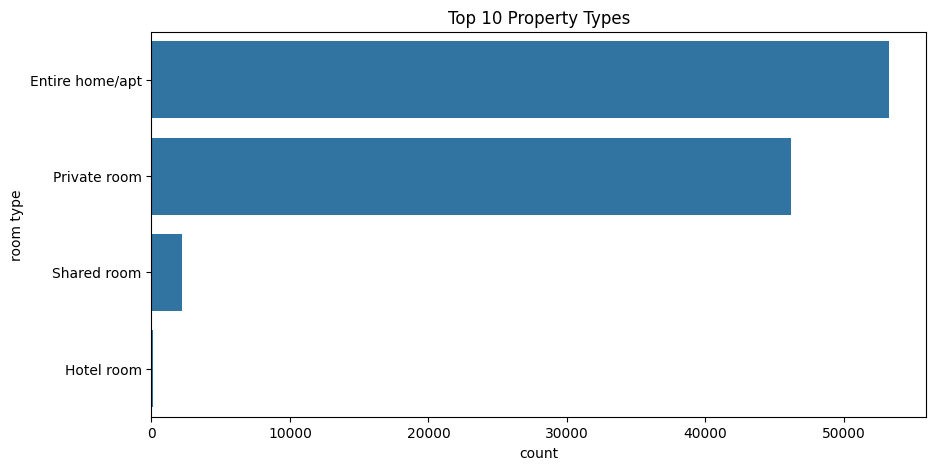

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='room type', order=df['room type'].value_counts().index[:10])
plt.title("Top 10 Property Types")
plt.show()

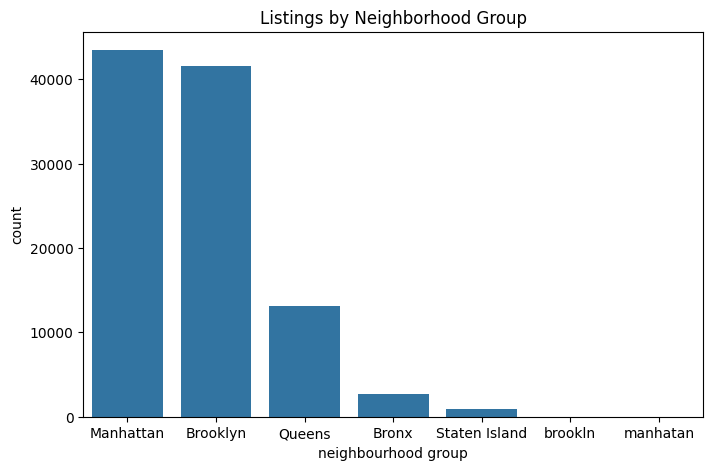

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='neighbourhood group', order=df['neighbourhood group'].value_counts().index)
plt.title("Listings by Neighborhood Group")
plt.show()


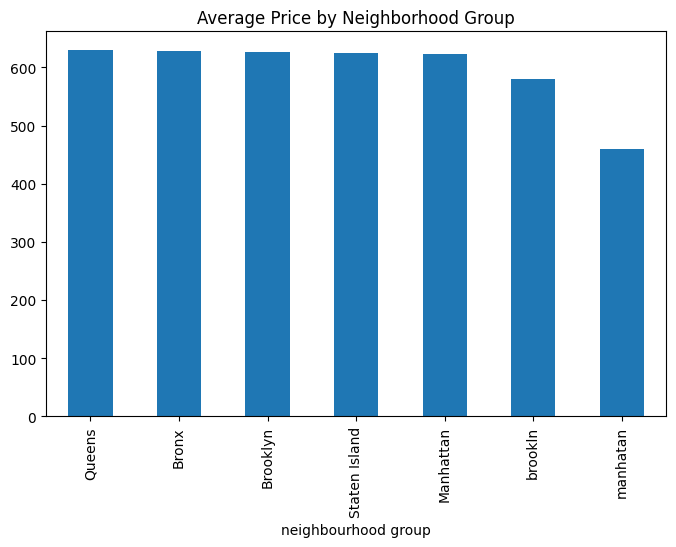

In [10]:
avg_price = df.groupby('neighbourhood group')['price'].mean().sort_values(ascending=False)
avg_price.plot(kind='bar', figsize=(8,5), title="Average Price by Neighborhood Group")
plt.show()


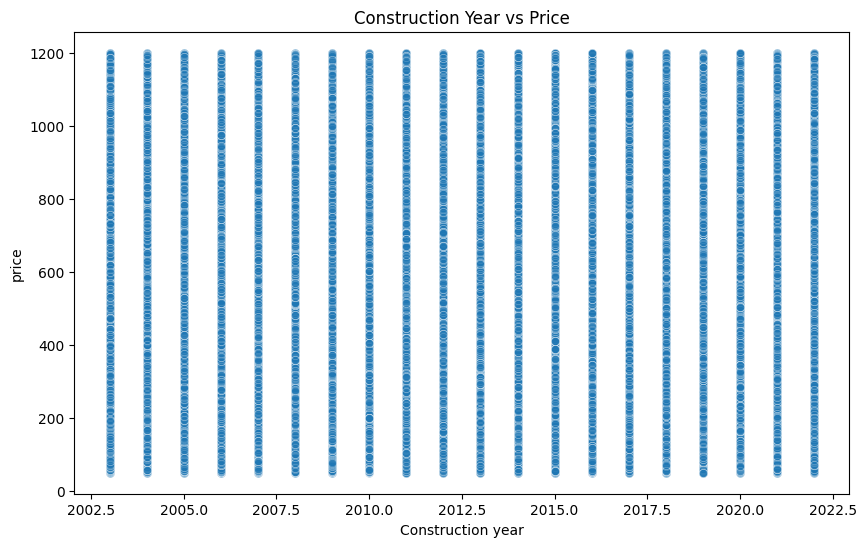

In [12]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Construction year', y='price', alpha=0.5)
plt.title("Construction Year vs Price")
plt.show()

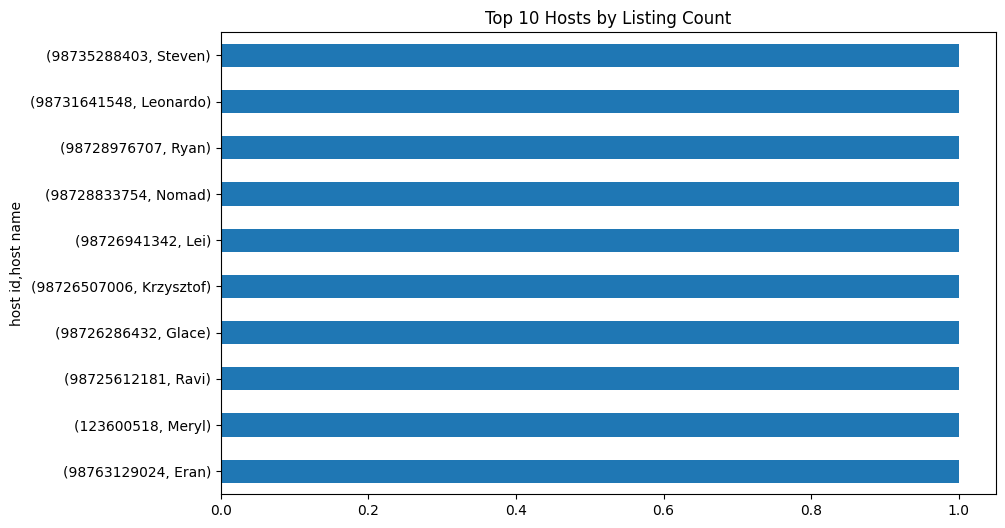

In [13]:
top_hosts = df.groupby(['host id','host name']).size().sort_values(ascending=False).head(10)
top_hosts.plot(kind='barh', figsize=(10,6), title="Top 10 Hosts by Listing Count")
plt.show()


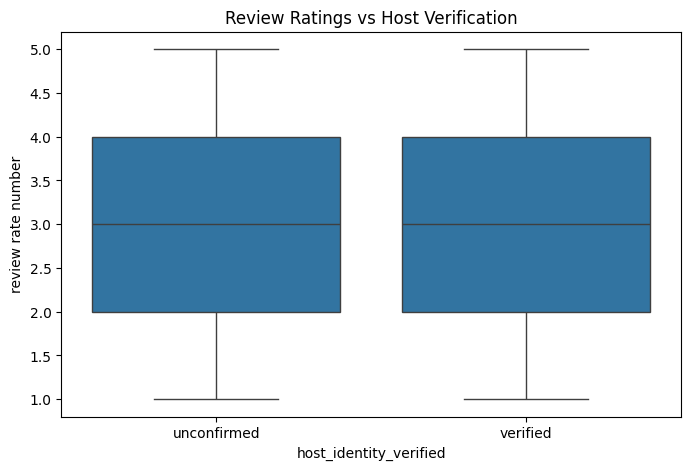

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='host_identity_verified', y='review rate number')
plt.title("Review Ratings vs Host Verification")
plt.show()

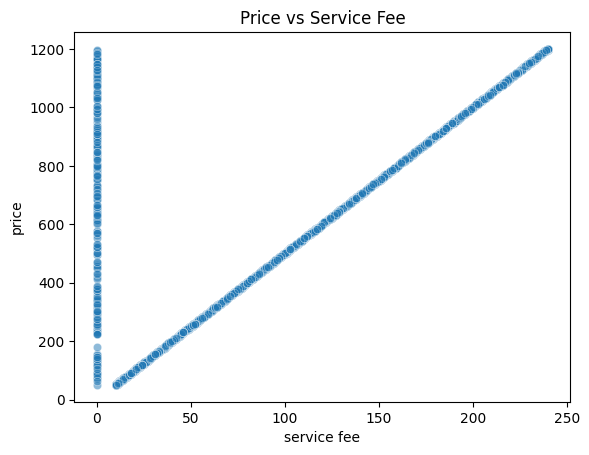

Correlation: 0.9940151832598451


In [16]:
sns.scatterplot(data=df, x='service fee', y='price', alpha=0.5)
plt.title("Price vs Service Fee")
plt.show()

print("Correlation:", df['price'].corr(df['service fee']))


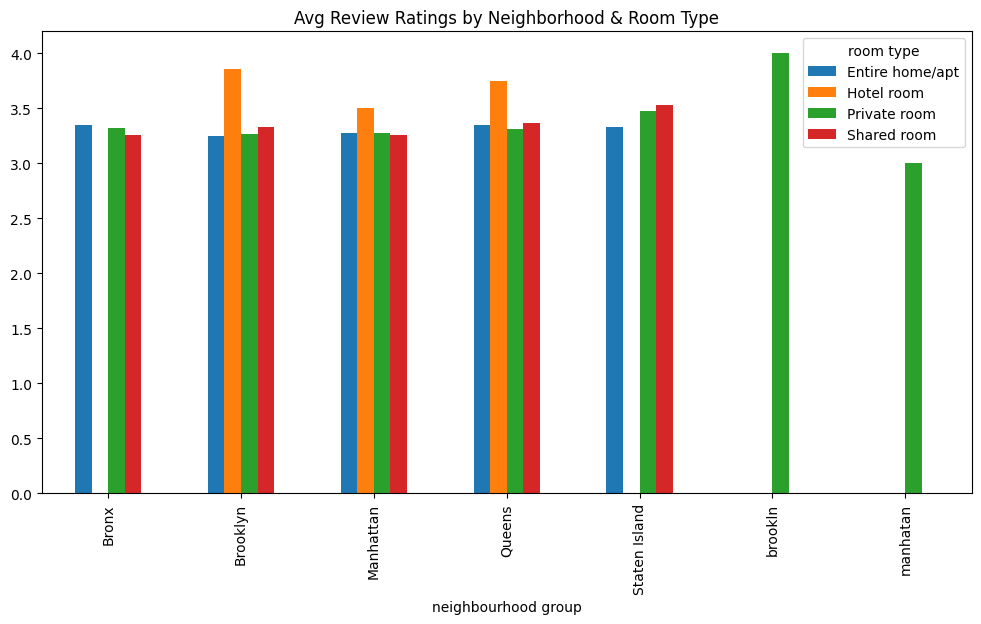

In [17]:
avg_reviews = df.groupby(['neighbourhood group','room type'])['review rate number'].mean().unstack()
avg_reviews.plot(kind='bar', figsize=(12,6), title="Avg Review Ratings by Neighborhood & Room Type")
plt.show()


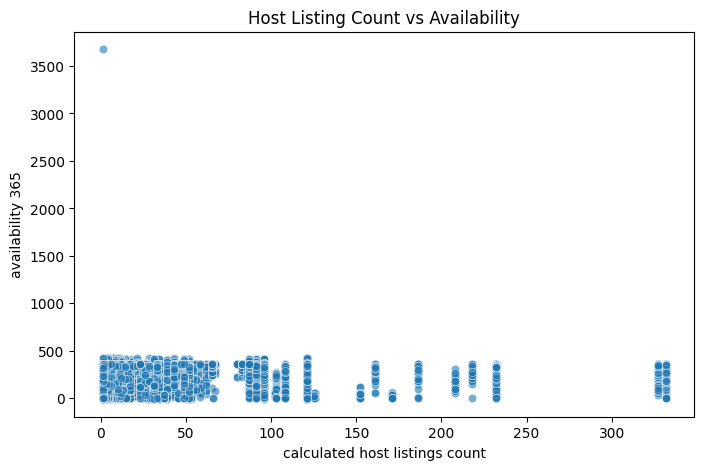

Correlation: 0.15931755281954837


In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='calculated host listings count', y='availability 365', alpha=0.6)
plt.title("Host Listing Count vs Availability")
plt.show()

print("Correlation:", df['calculated host listings count'].corr(df['availability 365']))


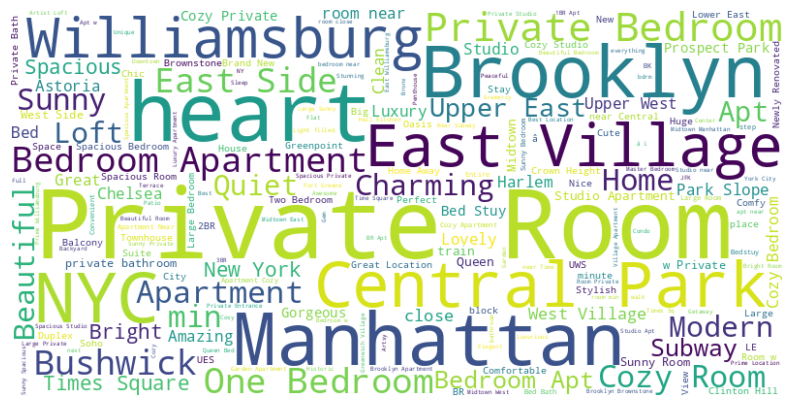

In [19]:
text = " ".join(str(name) for name in df['NAME'])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


Mean Absolute Error (MAE): 1.616619269633094
R2 Score: 0.997183457249333


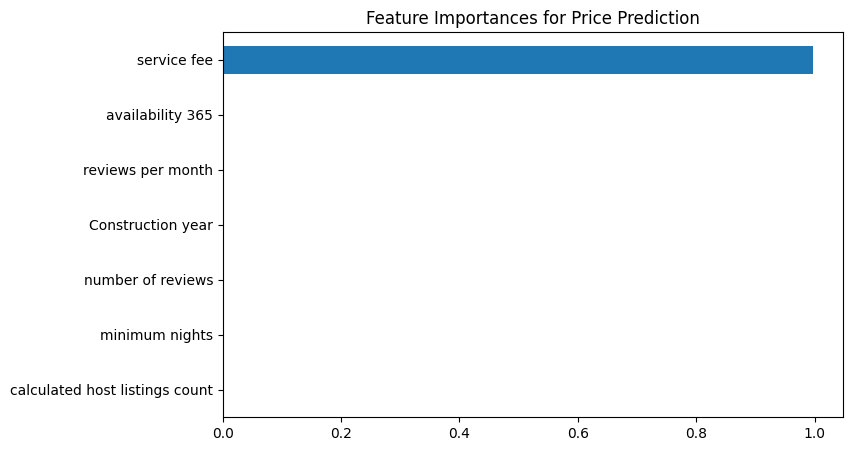

In [21]:
# ---------------------------
# Machine Learning: Price Prediction
# ---------------------------

# Select useful numerical features
features = ['service fee', 'minimum nights', 'number of reviews',
            'reviews per month', 'availability 365', 'Construction year',
            'calculated host listings count']

# Drop rows with missing price values
ml_df = df[features + ['price']].dropna()

X = ml_df[features]
y = ml_df['price']

# Split train-test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Model Evaluation
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Feature Importances
feat_importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8,5))
feat_importances.plot(kind='barh')
plt.title("Feature Importances for Price Prediction")
plt.show()

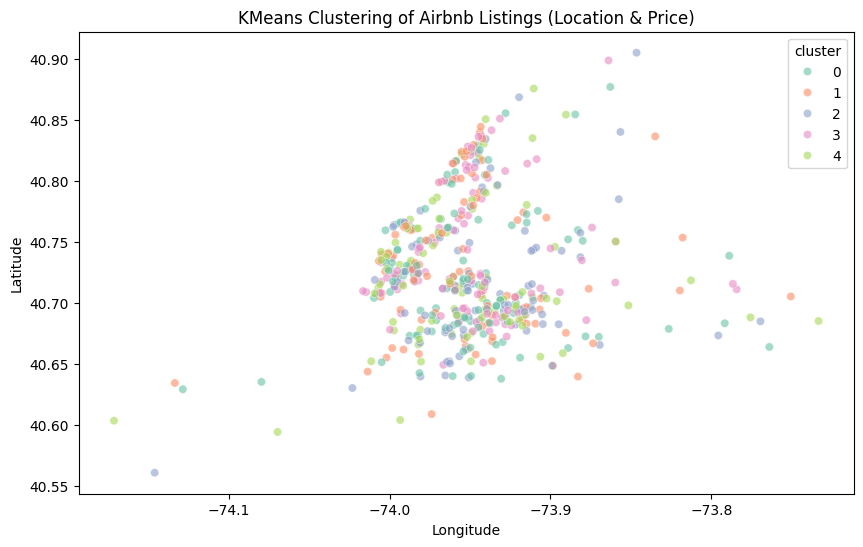

In [22]:
# ---------------------------
# K-Means Clustering of Listings
# ---------------------------
from sklearn.cluster import KMeans

# Use latitude, longitude, and price for clustering
cluster_df = df[['lat', 'long', 'price']].dropna()

# Limit extreme values for clustering stability
cluster_df = cluster_df[cluster_df['price'] < 1000]

# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_df['cluster'] = kmeans.fit_predict(cluster_df[['lat','long','price']])

# Plot clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=cluster_df.sample(500), x='long', y='lat', hue='cluster', palette="Set2", alpha=0.6)
plt.title("KMeans Clustering of Airbnb Listings (Location & Price)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Interactive Map with Plotly
fig = px.scatter_mapbox(cluster_df.sample(1000),
                        lat="lat", lon="long", color="cluster", size="price",
                        color_continuous_scale=px.colors.cyclical.IceFire,
                        size_max=10, zoom=10,
                        mapbox_style="carto-positron",
                        title="Airbnb Listing Clusters in NYC")
fig.show()
